In [12]:
from IPython.display import Image

# 10. 동적/동영상 비젼 (video analysis) 

## 컴퓨터 비젼에서의 동영상 

- 컴퓨터 비젼에서는 동영상은 시간적으로 연속된 이미지들로 처리됨 

 즉, 
    $ V = I(t),   t = 0, 1, 2, ... $

- fps (frame per second)
     - 사람을 30 fps 정도면 자연스럽게 느낌. 요즘 고품질 영화나 콘텐츠는 60 fps
     - 보통 응요에서는 5 fps 정도로 처리하면 실시간성으로 인정  

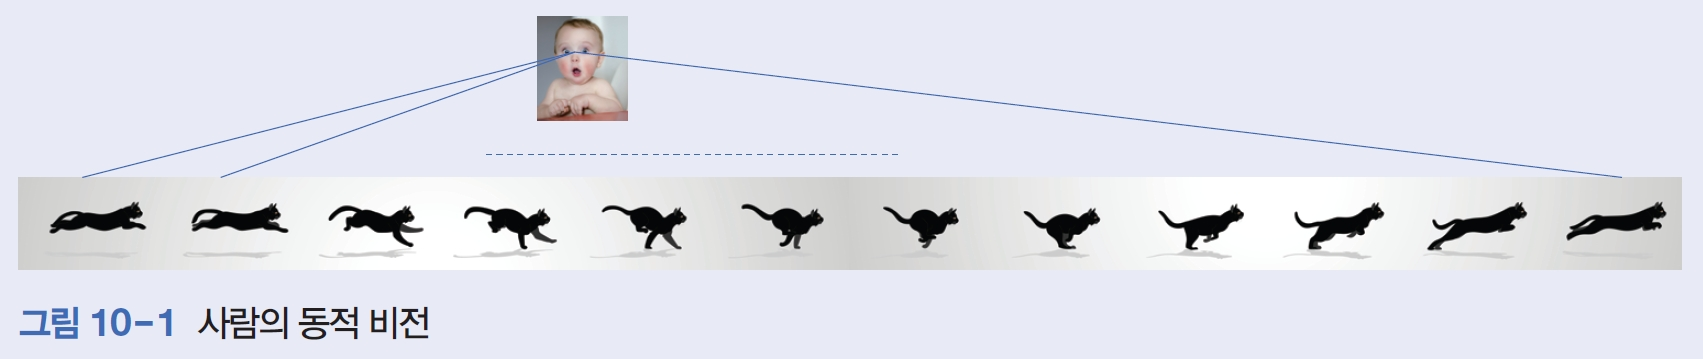

In [3]:
Image("그림 10-1.jpg", width=720)

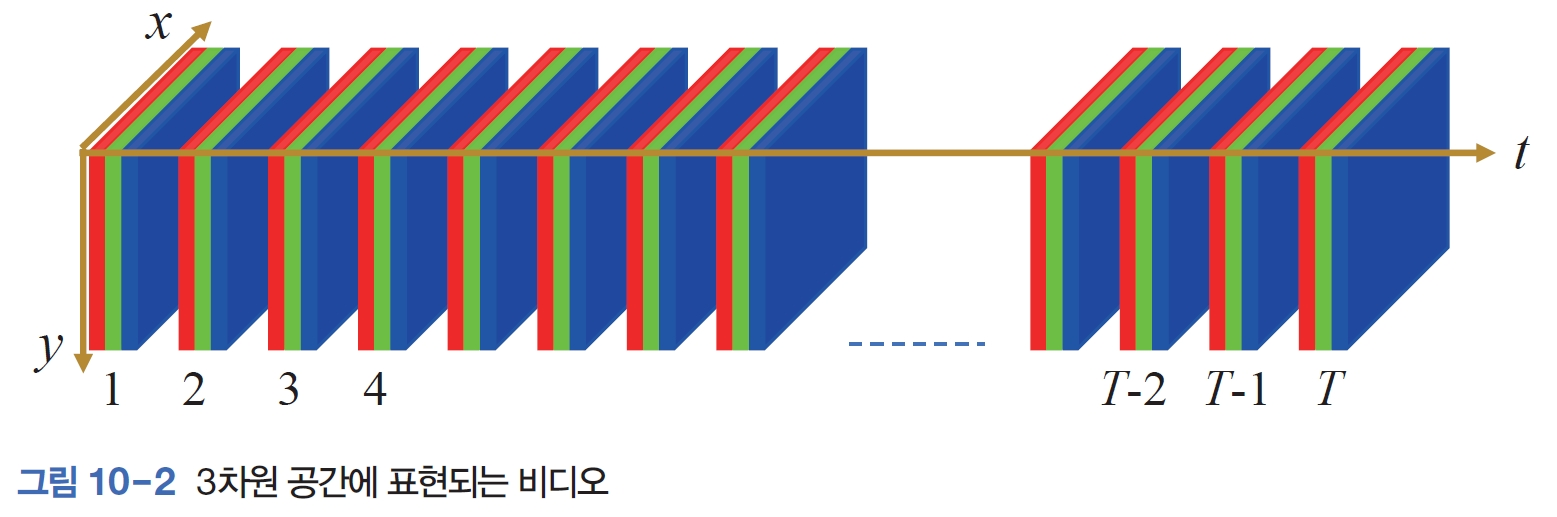

In [3]:
Image("그림 10-2.jpg", width=720)

## Handling Video Input and Display   

 - cv2.VideoCapture(video_file) # video file or 0, 1, 2 (camera number)
 - cv2.imshow("widow_tile", image)  # works in local machine well

In [7]:
import cv2

# 1. video open 
video_file  =  "tcmr_input2.mp4" # video file or 0, 1, 2 (camera number)
cap = cv2.VideoCapture(video_file)

# 2. read one frame by one frame 
while cap.isOpened():
    ret, frame = cap.read()  # frame has    
    # ret = False when video ends 
    if not ret:
        print("비디오 영상 재생이 완료되었습니다.")
        break
    cv2.imshow("vid", frame)
    k = cv2.waitKey(30) # waits 30 ms
    if k == ord('q'):
        break
           
cap.release() 

### using youtube video
- download
- get the streaming link 

In [ ]:
!pip install yt_dlp

In [26]:
# yt_dlp youtibe_video_url

# due to security reasons, it can be blocked from youtube
import yt_dlp
def get_youtube_streamlink(youtube_url):

    # 1. yt-dlp를 이용하여 유튜브에서 실제 비디오 스트림 URL 추출
    ydl_opts = {
        # 720p 이하의 mp4 포맷 중 오디오가 포함된 비디오 선택 (RTX 4090이라도 실시간 스트리밍 대역폭 고려)
        'format': 'best[ext=mp4][height<=720]/best[height<=720]',
        'quiet': True,
        'noplaylist': True,
        'cookiesfrombrowser': ('chrome',),  
    }

    print("유튜브 비디오 스트림 주소를 추출 중입니다...")
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(youtube_url, download=False)
        # OpenCV가 직접 읽을 수 있는 실시간 재생용 원격 URL 가공
        video_stream_url = info['url']
        print(video_stream_url)
        return video_stream_url    

### 대표적인 동영상 접근 방식

- 한 이미지에서의 정보를 추출하여 이를 시간적으로 **연결** 시키는 방식 
- 두개의 t에서의 이미지를 **비교**하여 차이를 분석하는 방식

## 1. 배경제거 (background substraction) 

- 물제가 없는 배경만 있는 이지지 상태와 비교를 통해서 물체의 유무 위치 이동 등의 정보를 솩보하는 방법
- $ d(y,x, t) =  | I(y,x, 0)  - I f(y, x, t)|,   t = 1. \cdots T $  


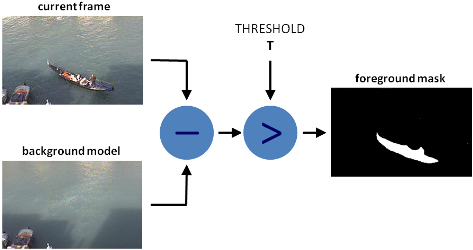

In [20]:
Image("Background_Subtraction_Tutorial_Scheme.png", width=640)

In [32]:
import cv2
import sys

#  Initialize OpenCV VideoCapture with the stream URL/Fle
cap = cv2.VideoCapture("cctv_highway.mp4") 
if not cap.isOpened():
    print("[Error] Could not open the video stream.")
    sys.exit()

# 4. Create the Background Subtractor object (MOG2 is a Gaussian Mixture-based model)
# history=500: number of frames used to learn and model the background
# varThreshold=16: variance threshold to decide whether a pixel belongs to foreground or background
# detectShadows=True: automatically detects and marks shadows in gray color (127)
bg_subtractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=25, detectShadows=True)

print("Starting Background Subtraction. Press 'q' to quit.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Video stream ended or buffer underflow.")
        break

    # Optional: Resize the frame if it's too large to display comfortably
    frame = cv2.resize(frame, (854, 480))

    # 5. Apply the background subtractor to get the foreground mask
    # Output layout: White (255) = Foreground, Gray (127) = Shadow, Black (0) = Background
    fg_mask = bg_subtractor.apply(frame)

    # 6. Post-processing (Optional cleaning for students)
    # Use a threshold to eliminate shadows (turn gray 127 into black 0) leaving pure white foreground
    _, fg_mask_cleaned = cv2.threshold(fg_mask, 250, 255, cv2.THRESH_BINARY)
    
    # Apply morphological opening to eliminate small pixel noise/isolated white dots
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    fg_mask_cleaned = cv2.morphologyEx(fg_mask_cleaned, cv2.MORPH_OPEN, kernel)

    # 7. Display the results in separate windows
    #cv2.imshow('Original YouTube Video', frame)
    #cv2.imshow('Raw FG Mask (with Shadows)', fg_mask)
    #cv2.imshow('Cleaned FG Mask (Noise Removed)', fg_mask_cleaned)

    frame_merged = cv2.vconcat([frame, cv2.cvtColor(fg_mask_cleaned, cv2.COLOR_GRAY2BGR)])
    frame_merged = cv2.resize(frame_merged, (frame_merged.shape[1]//2, frame_merged.shape[0]//2))
    cv2.imshow('bg-sub', frame_merged)

    # Press 'q' on the window to exit the loop
    if cv2.waitKey(30) & 0xFF == ord('q'):
        print("Terminated by user.")
        break

# Clean up resources
cap.release()
cv2.destroyAllWindows()
for i in range(5): cv2.waitKey(1)
print("Resources released cleanly.")

Starting Background Subtraction. Press 'q' to quit.
Video stream ended or buffer underflow.
Resources released cleanly.


## 2. 광류분석 (Optical flow analysis) 

### 밝기항상성 (brightness constancy) 가정 

- 물체 특정 위치의 밝기가 (잛은 시간에는) 동일하다는 가정  (조명, 물체의 자세 등의 영향을 무시): 
     $$  I(y(t), x(t), t) = const $$
- 한 화소 위치에서의 밝기의 변화하는 방향을 통해서 해당 위치의 물체가 어디로 이동을 하고 있는지를 알 수 있음 

   - 위 식을 $t$ 로 미분

       $$ \frac{\partial I}{\partial y} * \frac{dy}{dt} + \frac{\partial I}{\partial x} * \frac{dx}{dt} +   \frac{\partial I}{\partial t} = 0 $$ 
       
   - $ \bf{v} = (v_y, v_x) = (\frac{dy}{dt}, \frac{dx}{dt}) $ 을 대입
     
       $$ \frac{\partial I}{\partial y} v_y + \frac{\partial I}{\partial x}  v_x + \frac{\partial I}{\partial t}   = 0  $$
                      
   - 알아내고자 하는 변수는 $v_x$, $v_y$ 두 개인데, 주어진 수식은 하나 뿐 (underdetermined 방적식)

####  예) 아래 노란 화소
- $ -1 v_y + 2 v_x + 1 = 0 $    ($ \frac{\partial I}{\partial y} = -1$, $\frac{\partial I}{\partial x} =2 $, $\frac{\partial I}{\partial t} = 1  $)     
- $v_x, v_y$를 결정 할 수 없음

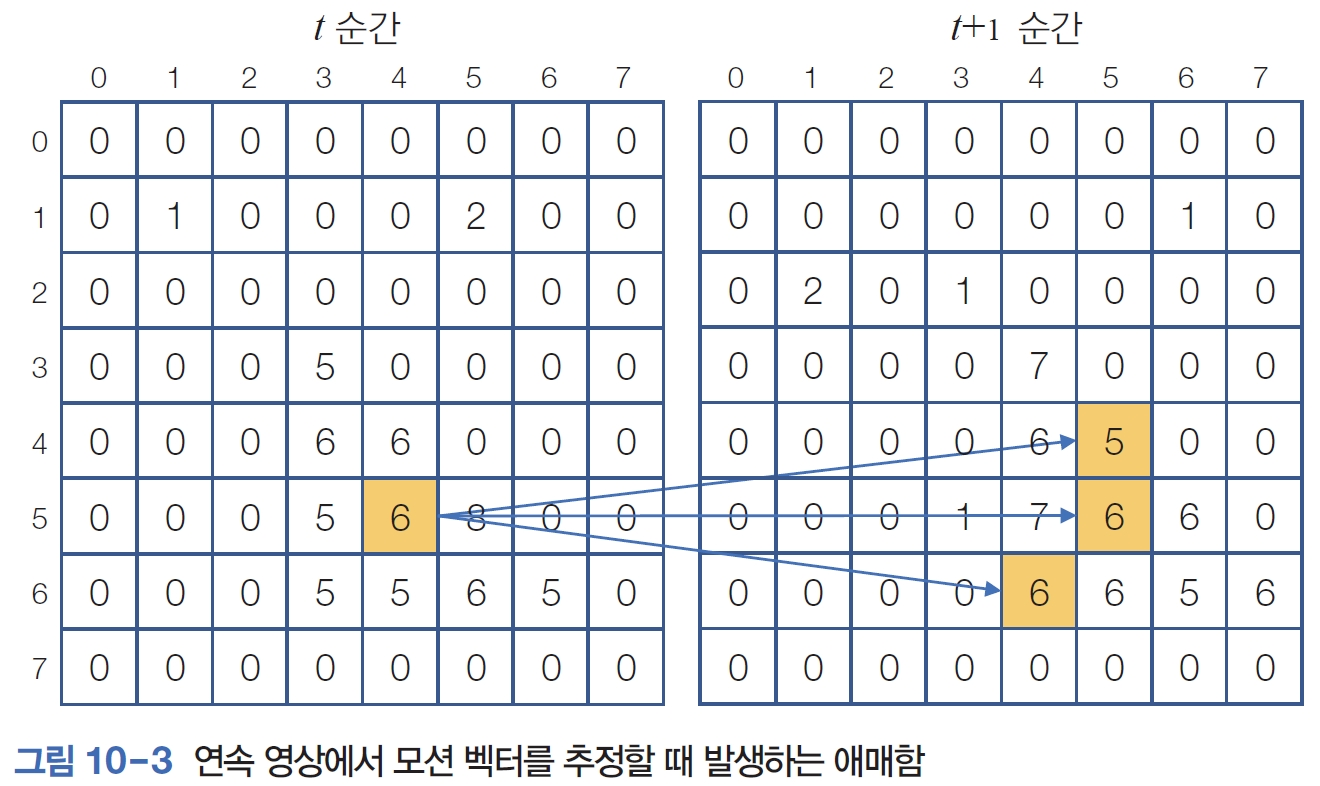

In [7]:
Image("그림 10-3.jpg", width=480)

 ####  광류 알고리즘
    
- 이웃한 화소들간에 (vx, vy)는 연속적일 가능성이 매우 높다는 가정을 함.(같은 물체에 속한 점이라면)
  
- 대표적인 알고리즘 들   
   - Lucas-Kanade 알고리즘  (지역 알고리즘)
   - Horn-Schunk 알고리즘   (전역 알고리즘)    
   - Farneback 알고리즘 (전화소 알고리즘)  

- 응용 분야 
    - 물체 추적, 광 마우스 등 

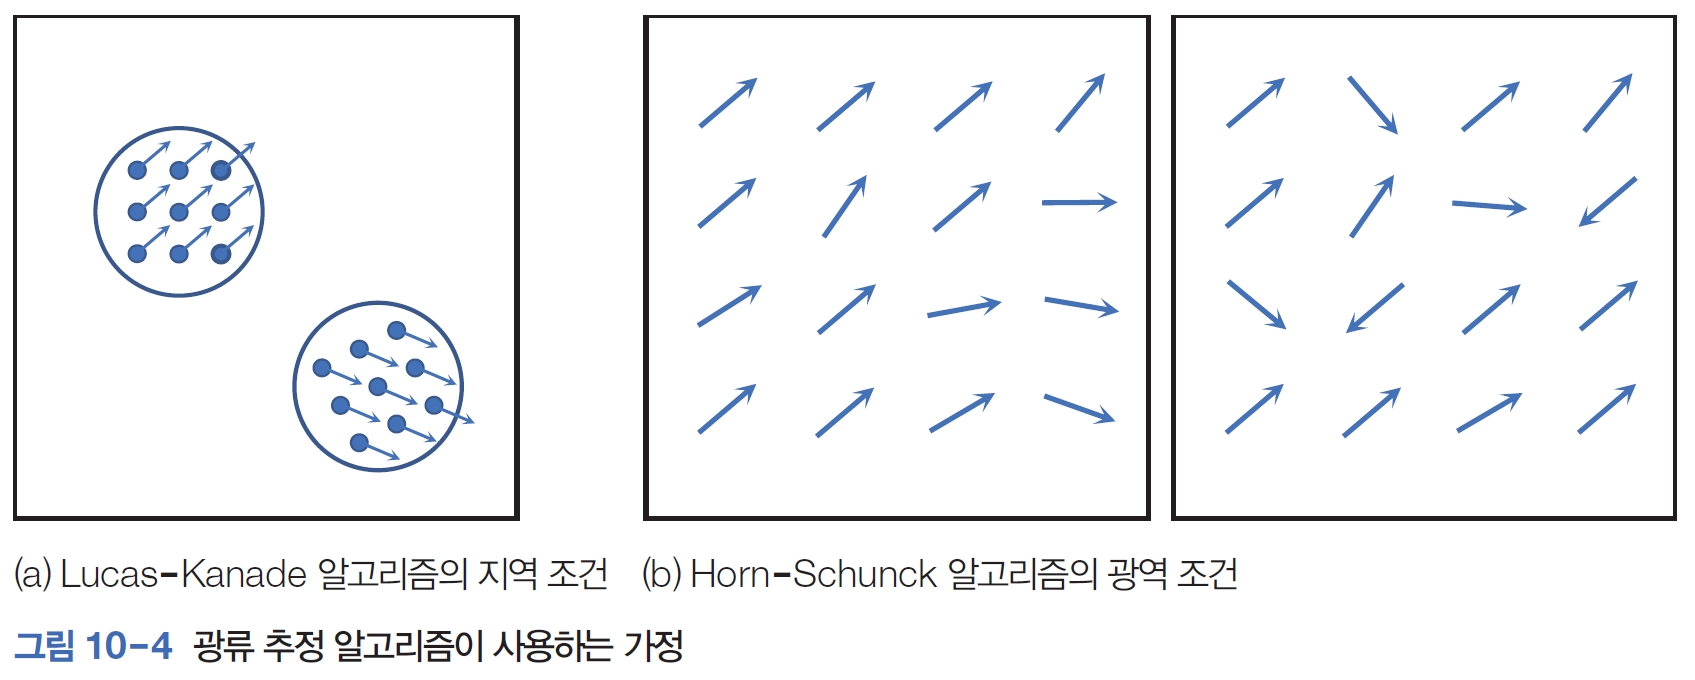

In [9]:
Image("그림 10-4.jpg", width=720)

### Franeback 사용법 

In [34]:
import cv2
import numpy as np

# 1. 로컬 비디오 파일 열기
cap = cv2.VideoCapture("cctv_highway.mp4") 

ret, first_frame = cap.read()
if not ret:
    print("비디오를 열 수 없습니다.")
    exit()

first_frame = cv2.resize(first_frame, (854, 480))
prvs = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)

# 2. 모션 흐름 시각화를 위한 HSV 이미지 버퍼 생성
hsv = np.zeros_like(first_frame)
hsv[..., 1] = 255 # 채도(Saturation)는 최대 고정

print("Farneback 전밀도 추적 시작. 'q'를 누르면 종료됩니다.")
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (854, 480))
    next_img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 3. Gunnar Farneback 알고리즘으로 전방향 고밀도 흐름 계산
    # 두 프레임 사이의 모든 x, y 픽셀 이동 변위(dx, dy)가 flow 배열에 담김
    flow = cv2.calcOpticalFlowFarneback(prvs, next_img, None, 
                                        pyr_scale=0.5, levels=3, winsize=15, 
                                        iterations=3, poly_n=5, poly_sigma=1.2, flags=0)

    # 4. 카테시안 좌표(dx, dy)를 극좌표(크기, 각도)로 변환
    magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # 5. 움직임의 방향(angle)을 HSV의 색상(Hue, 0~180)으로 맵핑
    hsv[..., 0] = angle * 180 / np.pi / 2
    
    # 6. 움직임의 크기(magnitude)를 HSV의 명도(Value, 0~255)로 맵핑
    # 정규화를 통해 너무 작거나 큰 움직임의 가독성을 보정
    hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

    # 7. 완성된 HSV 지도를 BGR로 변환하여 출력
    rgb_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    frame_merged = cv2.vconcat([frame, rgb_flow])
    frame_merged = cv2.resize(frame_merged, (frame_merged.shape[1]//2, frame_merged.shape[0]//2))
    cv2.imshow('bg-sub', frame_merged)
   
    # 현재 프레임을 다음 프레임의 '이전 프레임'으로 저장
    prvs = next_img

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Farneback 전밀도 추적 시작. 'q'를 누르면 종료됩니다.


### Lucas-Kande 사용법

In [35]:
import cv2
import numpy as np

# 1. 로컬 비디오 파일 열기
cap = cv2.VideoCapture("cctv_highway.mp4")

# 2. Shi-Tomasi 코너 검출기 설정 (LK 알고리즘이 추적할 첫 특징점들 찾기용)
feature_params = dict(maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)

# 3. Lucas-Kanade Optical Flow 파라미터 설정
# winSize: 주변 몇 픽셀 영역을 묶어서 계산할지 지정
lk_params = dict(winSize=(15, 15), maxLevel=2,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

# 4. 첫 프레임 읽기 및 그레이스케일 변환
ret, old_frame = cap.read()
if not ret:
    print("비디오를 열 수 없습니다.")
    exit()
    
old_frame = cv2.resize(old_frame, (854, 480))
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

# 첫 프레임에서 좋은 특징점 검출
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

# 추적선을 그리기 위한 빈 캔버스 마스크 생성
mask = np.zeros_like(old_frame)

print("Lucas-Kanade 추적 시작. 'q'를 누르면 종료됩니다.")
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    frame = cv2.resize(frame, (854, 480))
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 5. 이전 특징점(p0)들이 새 프레임(frame_gray)에서 어디로 이동했는지 계산
    # p1: 이동한 좌표, st: 추적 성공 여부(1=성공, 0=실패)
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # 성공적으로 추적된 점들만 필터링
    if p1 is not None:
        good_new = p1[st == 1]
        good_old = p0[st == 1]

        # 이동 궤적선 그리기
        for i, (new, old) in enumerate(zip(good_new, good_old)):
            a, b = new.ravel()
            c, d = old.ravel()
            # 실시간 궤적 그리기
            mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), (0, 255, 0), 2)
            frame = cv2.circle(frame, (int(a), int(b)), 5, (0, 0, 255), -1)

        img = cv2.add(frame, mask)
        cv2.imshow('Lucas-Kanade Sparse Optical Flow', img)

        # 다음 루프를 위해 현재 프레임 정보 업데이트
        old_gray = frame_gray.copy()
        p0 = good_new.reshape(-1, 1, 2)
        
        # 주기적으로 특징점이 유실되면 다시 검출
        if len(p0) < 20:
            p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
            mask = np.zeros_like(old_frame) # 라인 리셋

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Lucas-Kanade 추적 시작. 'q'를 누르면 종료됩니다.


###  3) 추적 

  - 앞서 언급한 문제들로 Optical flow 방식의 응용 범위는 제한적 
     
#### Tracking by detection 방식

- 기존의 tracking이 frame 간의 상관성을 이용하여 대응되는 화소를 찾아 내는 방식 이라면 화면마다 detection 수행을 하고 이들간의 대응을 찾는 방식 
- 매번 detection을 하여야하기 때문에 단순 tracking 기법에 비하여 계산양이 많으나, Re-identification 등에 유리하고, 높은 성능의 detection 방식을 활용할 수있어 주요한 방식이 되엇음. 

- 해결해야할 문제
   - (가까이에 있는 유사한) 대응하는 검출 결과가 다수개 존재 
   - 검출이 잘 안되서 사라졌다가 다시 나타났다하는 문제  (Re-Identification) 

#### 문제의 종류 
- VOT (Visual object tracking): 다소 오래된 문제 정으로, 맨처음 물제를 사람이 지정해주고 이를 추적하는 문 (아마도 Tracking by Detection 이전에 주로 사용했던 문제) 
- MOT (Multi-object tracking):  물체의 종류만을 정해죽 이의 검출과 추정을 하는 문제 
- Batch 방식 vs Online 방식 문제: 시간적으로 이전, 이후 frame의 접근이 가능한 (저장된 경우) 문제, 이전 프레임들만을 사용할 수 있는 문제   
- Multi-camera : 다수개의 카메라에서 촬영된 물체를 추적하는 문제 (한 카메라에서 사라져서 다른 카메라에 나타는 물체의 동일성을 확인해야함)


#### 성능 척도 

 -  MOTA (MOT Accuracy) = 1 -  (전체 시간 동안 FN, FP, IDSW 수)/(전체 시간 중 정답의 갯수)
 -  IDSW: 물체 아이디를 잘못 한 경우. 예를 들어 동일 한 물체인데 중간에 다른 물체로 ID를 변환하면 한번의 실수로 판단) 

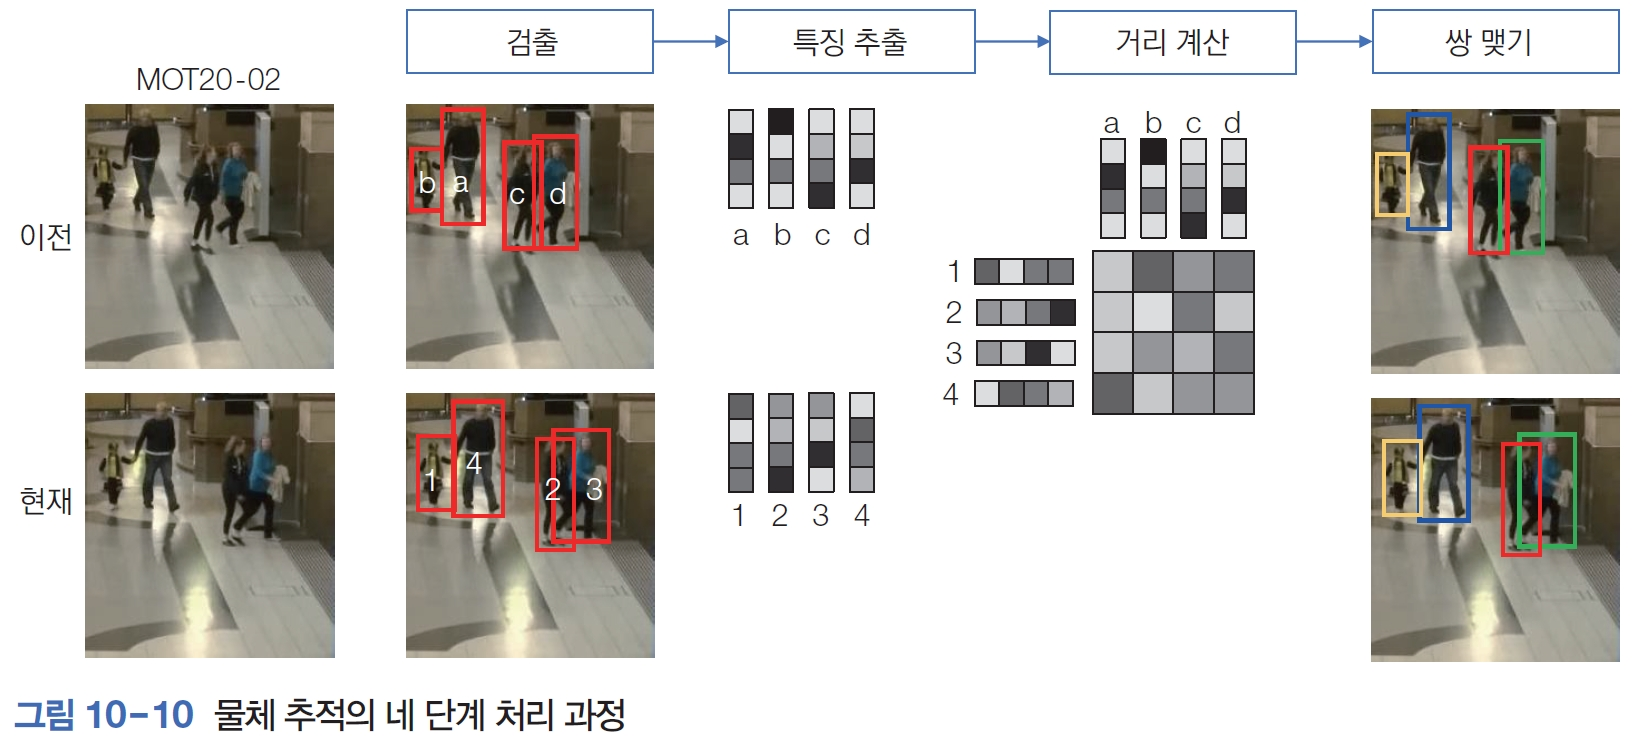

In [3]:
Image("그림 10-10.jpg", width=720)

#### 3) SORT and DeepSORT

1. SORT 개요
   - Simple Online and Realtime Tracking의 약자
   - 딥러닝 모델(YOLO 등)이 찾아낸 탐지 상자(Bounding Box)의 위치 데이터 정보만 활용하여 추적
   - 구조가 단순하면서도 연산 속도가 매우 빨라 실시간 시스템에서 널리 활용.

2. SORT 동작 원리
   - 두 가지 핵심 알고리즘의 결합
   - 위치 예측 (Kalman Filter): 객체의 이전 이동 속도와 방향을 기반으로 다음 프레임에서 이 객체가 어디에 있을지 수학적으로 예측
   - 데이터 매칭 (Hungarian Algorithm): 새로 탐지된 객체들과 칼만 필터가 예측한 위치 사이의 IoU(Intersection over Union: 교집합 영역 넓이 비율)를 계산. 면적이 가장 많이 겹치는 쌍을 헝가리안 알고리즘을 통해 최적의 조합으로 연결하여 동일한 ID를 부여.

3. DeepSORT 동작 원리
    - SORT는 빠르지만, 객체가 다른 물체에 잠시 가려지거나(Occlusion) 카메라 앵글이 격하게 흔들리면 ID가 쉽게 바뀌는 치명적인 약점
    - 딥러닝 feature 추출 추가: 객체의 '위치 정보'뿐만 아니라, 객체의 '외형 특징(Visual Appearance Feature)'을 추출하는 작은 CNN
    - 매칭 방식의 고도화: 박스가 겹치는 정도(IoU) + "이전 프레임의 사람 옷 색상/생김새와 지금 사람이 얼마나 닮았는가?"를 계산(Re-Identification)

In [58]:
import cv2
import sys
from ultralytics import YOLO

print("[INFO] Loading YOLOv11 nano model...")
model = YOLO("yolo11n.pt")

# Analyze target video
cap = cv2.VideoCapture("tracking.mp4")

if not cap.isOpened():
    print("[Error] Video file not found or cannot be opened.")
    sys.exit()

print("[START] Pipeline running. Press 'q' inside the video window to quit.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Downsize resolution for smooth rendering and memory efficiency
    frame = cv2.resize(frame, (frame.shape[1] // 2, frame.shape[0] // 2))

    # ==============================================================================
    # [THE FIX] Standard, native Ultralytics tracking engine
    # This automatically runs highly optimized BoT-SORT / ByteTrack logic under the hood.
    # ==============================================================================
    results = model.track(
        source=frame, 
        persist=True,      # Tells YOLO to remember tracking IDs across frames
        classes=[0, 2],    # Filter for Person(0) and Vehicle/Car(2) only
        conf=0.4,          # Confidence threshold
        tracker="botsort.yaml", # Options: "botsort.yaml" or "bytetrack.yaml"
        verbose=False
    )
   
    # Pull out results and draw onto the frame
    for r in results:
        boxes = r.boxes
        # Ensure boxes exist and have assigned tracking IDs
        if boxes is not None and boxes.id is not None:
            # Move tensors to CPU and convert to standard numpy arrays
            xyxy_list = boxes.xyxy.cpu().numpy()
            id_list = boxes.id.cpu().numpy().astype(int)
            cls_list = boxes.cls.cpu().numpy().astype(int)

            #print(f"Tracking {len(id_list)} objects in this frame.")

            for xyxy, track_id, cls in zip(xyxy_list, id_list, cls_list):
                x1, y1, x2, y2 = map(int, xyxy)

                # Set display text based on object type
                label = "Person" if cls == 0 else "Vehicle"

                # Draw bounding box (Green)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                # Draw Track ID text label
                cv2.putText(
                    frame, 
                    f"{label} ID: {track_id}", 
                    (x1, y1 - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 
                    0.6, 
                    (0, 255, 0), 
                    2
                )

    cv2.imshow("YOLOv11 Native Tracking", frame)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("[FINISHED] Resource cleanup complete.")

[INFO] Loading YOLOv11 nano model...
[START] Pipeline running. Press 'q' inside the video window to quit.
[FINISHED] Resource cleanup complete.


### END